############
SCRIPT RUNNING
############
    FINISHED ACE FIGURE
############
SCRIPT FINISHED: time: 00:00:01
############


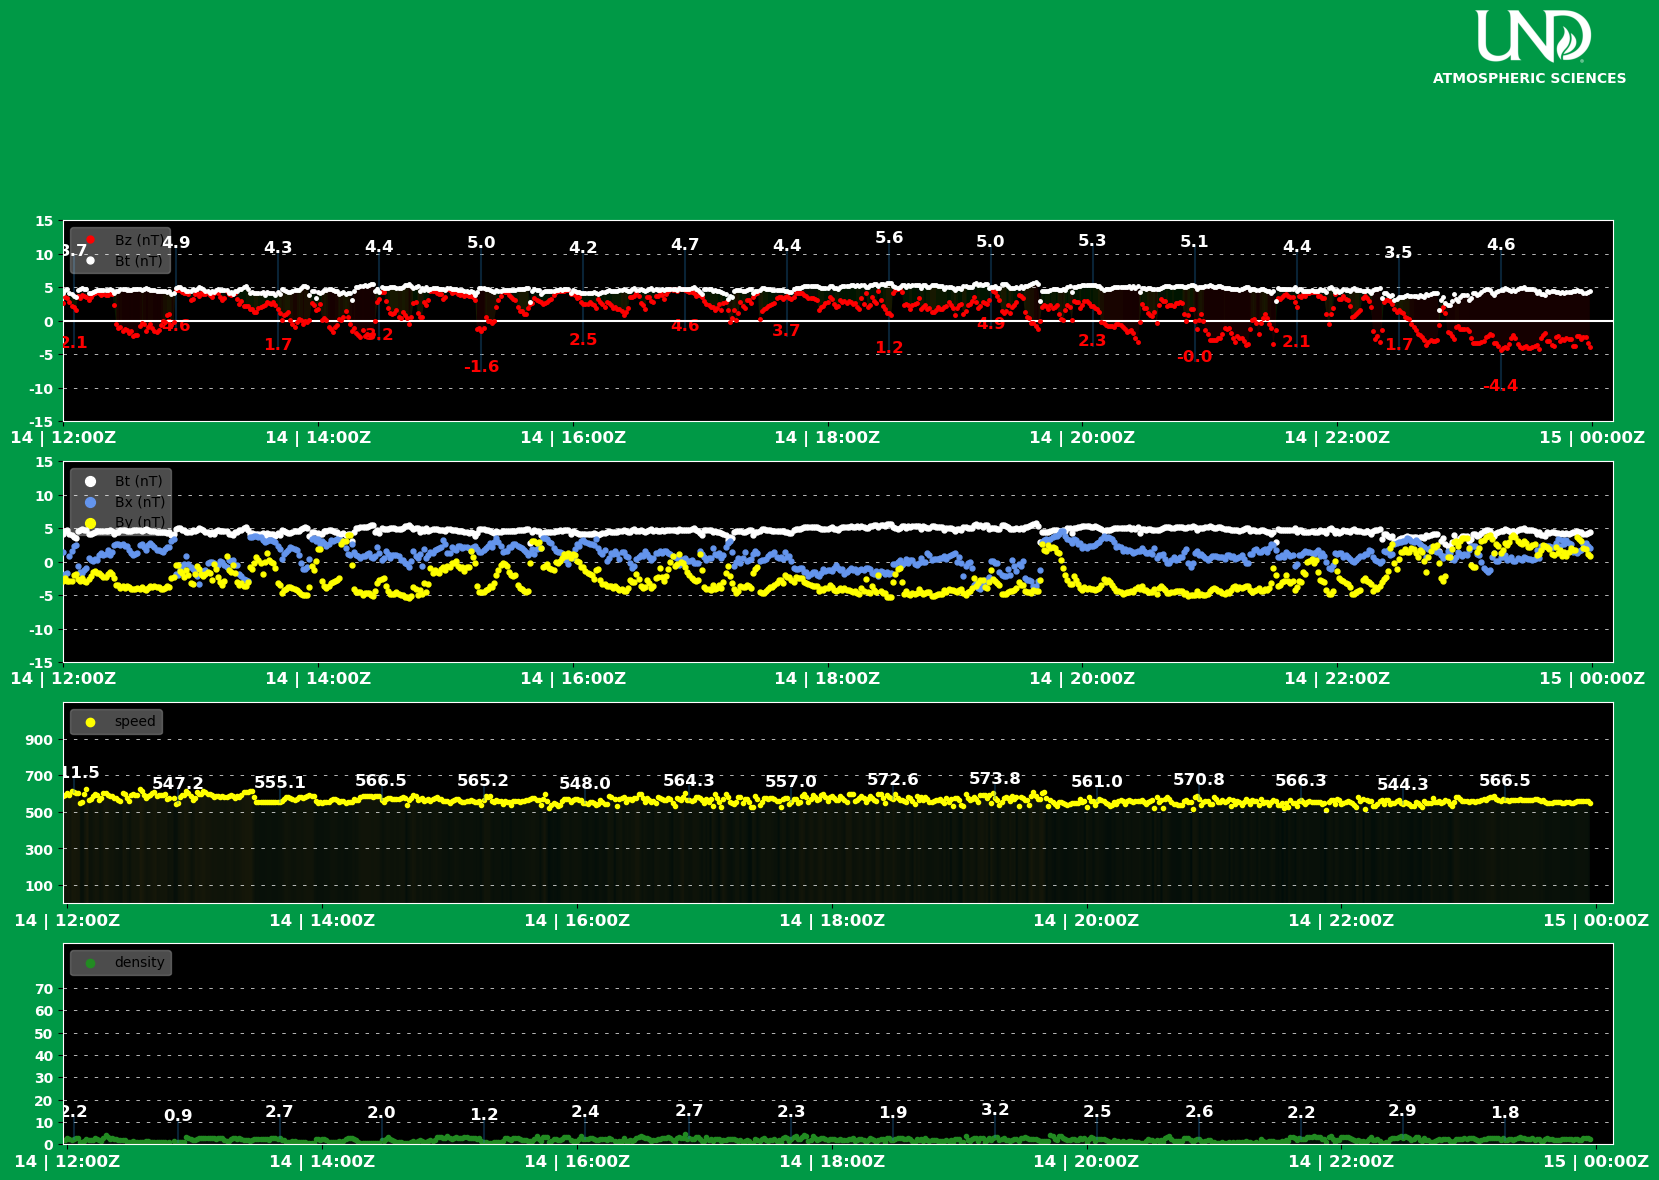

In [9]:
print("############\nSCRIPT RUNNING\n############")
import time as comp_time
st = comp_time.time()

import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import numpy as np
import math
from urllib.request import urlopen
from PIL import Image
import sys
import os

# # get script dir
# script_dir = os.path.dirname(os.path.abspath(__file__))

# # get the parent dir 
# project_root = os.path.abspath(os.path.join(script_dir, ".."))

# if project_root not in sys.path:
#     sys.path.append(project_root)
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))  # add parent dir
from get_data.get_spacewx_data import get_ace_data, get_kp_data

data = get_ace_data()

time_range = 12

### TIME UTILS ###
#####################################################
def time_utils(data, time_range=6, src='magswe'):

    mag_start_date_idx = find_nearest(data['mag_dates'], (data['mag_dates'][-1] - timedelta(hours=time_range)).replace(second=0, microsecond=0))
    mag_end_date_idx   = -1 
    pam_start_date_idx = find_nearest(data['pam_dates'], (data['pam_dates'][-1] - timedelta(hours=time_range)).replace(second=0, microsecond=0))
    pam_end_date_idx   = -1 

    travel_time = int(((1500000)/(find_latest_vals(data['speed']))/60))
    travel_time_delta = data['pam_dates'][pam_end_date_idx] - timedelta(minutes=travel_time)
    travel_time_delta_text = data['pam_dates'][pam_end_date_idx] - timedelta(minutes=travel_time+2)
    
    return [mag_start_date_idx, mag_end_date_idx], [pam_start_date_idx, pam_end_date_idx], [travel_time_delta, travel_time_delta_text]
    



### CHECK FOR VALID DICT KEYS ###
#####################################################
def check_dict_keys(dictionary, keys):
    for key in keys:
        if key not in dictionary:
            raise KeyError(f"INCOMPLETE DATA -- '{key}' data missing -- the data you are trying to plot may not be meant for this plot style, or there is incomplete data")
    

    
    
### REPLACE MISSIN DATA WITH NAN ###
#####################################################    
def replace_missing(array):
    for item in range(0, len(array)):
        if array[item] <= -999.9:
            array[item] = np.nan
    return array


### SIMPLE NAN INTERP FUNCTION ###
#####################################################
def interpolate_nans(array):
    nan_indices = np.isnan(array)
    valid_indices = ~nan_indices
    array[nan_indices] = np.interp(np.flatnonzero(nan_indices), np.flatnonzero(valid_indices), array[valid_indices])
    return array


### FIND IMF Y-LIMIT ###
#####################################################
def find_imf_limit(bt, bz):
    
    bt, bz = replace_missing(bt), replace_missing(bz)  
    max_val = np.nanmax(np.concatenate((abs(bt), abs(bz))))
    nearest_5 = int(math.ceil(max_val / 5.0)) * 5
    
    if (nearest_5 - max_val) <= 3:
        return (nearest_5 + 5) + 5
    else:
        return (nearest_5) + 5
    
     
    
### FIND NEAREST VALUE ###
#####################################################    
def find_nearest(array, value):
        array = np.asarray(array)
        idx = (np.abs(array - value)).argmin()
        return idx
    
    
    
### BUILD SWPC AURORA COLORMAP ###
#####################################################    
def build_aurora_cmap(): 
    from colour import Color
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.colors import ListedColormap
    
    color_list = ['#819b7c', '#5ea25c', '#3ba93a', '#01de00', '#6afd00', '#f1ff01', '#ffc900', '#fe8e00', '#fd3300', '#e80001', '#d80000',  '#d80000',  '#d80000',  '#d80000']

    aurora_cmap = ListedColormap([Color(c1).rgb for c1 in color_list ], 'my_list' )
    
    aurora_cmap_r = ListedColormap(aurora_cmap.colors[::-1])
    
    return aurora_cmap, aurora_cmap_r


### COMPUTE CURRENT VALUES ###
#####################################################
def find_latest_vals(data, bz=False):
    
    for item in reversed(data.tolist()):
        if not math.isnan(item):
            latest = item
            break
    # return -9999
    
    if bz == True:
        if latest > 0:
            bz_dir = 'NORTH'
        else:
            bz_dir = 'SOUTH'
        
        return np.round(latest,1), bz_dir
    else:
        return np.round(latest,1)

    
    
### CREATE AURORAL ACTIVITY STR ###
#####################################################
def find_g_level(kp_data):
    
    kp_data = float(kp_data[-1])
    
    g_levels = {
        0:' ', 1:' ', 2:' ', 3:' ', 4:' ',
        5:'| G1', 6:'| G2', 7:'| G3', 8:'| G4', 9:'| G5'
    }

    G = g_levels[int(kp_data)]

    if kp_data <= 3:
        activity = f'Quiet {G}'
    elif kp_data > 3 and a < 5:
        activity = f'Minor {G}'
    elif kp_data >= 5 and a < 7:
        activity = f'Moderate {G}'
    elif kp_data >= 7 and a < 9:
        activity = f'Active {G}'
    elif kp_data >= 9:
        activity = f'Very Active | {G}'
        
    return activity




#############
# BUILD MAG/SWE PLOT #
##################################

# MAKE SOME DATA CORRECTIONS AND TIME LOGIC CALCS
# USE UTIL FUNCTIONS 
mag_idx, pam_idx, travel_time = time_utils(data, time_range)

# get SWPC aurora colormap
aurora_cmap, aurora_cmap_r = build_aurora_cmap()

# build valid-date-string
valid_str = f"VALID: {data['mag_dates'][-1].strftime('%H:%M')}Z - {str.upper(data['mag_dates'][-1].strftime('%h'))} {data['mag_dates'][-1].strftime('%d')} {data['mag_dates'][-1].strftime('%Y')}"

# get KP data and current auroral activity 
kp_data = get_kp_data()
activity_str = find_g_level(kp_data['kp_index'])

# annotation increment 
ann_idx = time_range*4


data['density_intrp'] = interpolate_nans(replace_missing(data['density']))
data['speed_intrp'] = interpolate_nans(replace_missing(data['speed']))
data['bz_intrp'] = interpolate_nans(replace_missing(data['bz']))
data['bt_intrp'] = interpolate_nans(replace_missing(data['bt']))
data['by_intrp'] = interpolate_nans(replace_missing(data['by']))
data['bx_intrp'] = interpolate_nans(replace_missing(data['bx']))

#############
# BUILD FIGURE #
##################################

#=======================================================================================================================#
# DECLARE BASIC FIGURE PROPERTIES 
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 12), linewidth=10, edgecolor='#009946')
fig.set_facecolor('#009946')

# DECLARE BASIC SUBPLOT PROPERTIES
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor('black')
    ax.tick_params(axis='x', labelsize=12, labelcolor='white')
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    ax.patch.set_alpha(1)
    ax.margins(0)
    ax.xaxis.set_major_formatter((mdates.DateFormatter('%d'+' | '+'%H:%M'+'Z')))
    ax.grid(which='major', axis='y', linestyle=(0, (5, 10)), color='white', linewidth=0.5)
    ax.spines["top"].set_color("white")
    ax.spines["left"].set_color("white")
    ax.spines["right"].set_color("white")
    ax.spines["bottom"].set_color("white")
    ax.spines["bottom"].set_color("white")
    #ax.axvline(x=travel_time[0], color='lightblue', linestyle='--')
#=======================================================================================================================#




#############
# PLOT DATA #
##################################

#=======================================================================================================================#    
# PLOT AXIS 1 DATA (MAGNETOMETER)
# use some simple math to find dynamic axis limits 
limit = find_imf_limit(data['bt'][mag_idx[0]:mag_idx[1]], data['bz'][mag_idx[0]:mag_idx[1]])
lbl1, lbl2, lbl3 = int(limit/3), int(limit/3) + int(limit/3), int(limit/3) + int(limit/3) + int(limit/3) 

ax1.set_ylim(-limit, limit)
ax1.set_yticks([-lbl3, -lbl2, -lbl1, 0, lbl1, lbl2, lbl3])
ax1.set_yticklabels([str(-lbl3), str(-lbl2), str(-lbl1), '0', str(lbl1), str(lbl2), str(lbl3)], color='white', weight='bold')
ax1.set_xlim(data['mag_dates'][mag_idx[0]], data['mag_dates'][mag_idx[1]] + timedelta(minutes=10))

ax1.axhline(y=0, color='white', linestyle='-', zorder=9)

# plot data 
ax1.plot(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bz'][mag_idx[0]:mag_idx[1]], 
            'r.', markersize=5, alpha=1, zorder=10, label='Bz (nT)')
ax1.plot(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bt'][mag_idx[0]:mag_idx[1]],
            'w.', markersize=5, alpha=1, zorder=10, label='Bt (nT)')


# data fill
polygon = ax1.fill_between(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bz_intrp'][mag_idx[0]:mag_idx[1]],  data['bt_intrp'][mag_idx[0]:mag_idx[1]], interpolate=True, color='none', alpha=0.1, zorder=3)
verts   = np.vstack([p.vertices for p in polygon.get_paths()])
filling = ax1.imshow(data['bz_intrp'][mag_idx[0]:mag_idx[1]].reshape(1, -1), cmap=aurora_cmap_r, aspect='auto', interpolation_stage='data', alpha=0.1,
                    extent=[verts[:, 0].min(), verts[:, 0].max(), verts[:, 1].min(), verts[:, 1].max()], label='IMF')
filling.set_clip_path(polygon.get_paths()[0], transform=ax1.transData)


# annotate data
for x, y in zip(data['mag_dates'][mag_idx[0]:mag_idx[1]][5 : : ann_idx], data['bz'][mag_idx[0]:mag_idx[1]].tolist()[5 : : ann_idx]):
    ax1.text(x, y-6, f"{np.round(y, 1)}", weight='bold', fontsize=12, color='red', alpha=1, ha='center', clip_on=True)
    ax1.add_line(matplotlib.lines.Line2D([x, x], [y, y-6], alpha=0.3))

for x, y in zip(data['mag_dates'][mag_idx[0]:mag_idx[1]][5 : : ann_idx], data['bt'][mag_idx[0]:mag_idx[1]].tolist()[5 : : ann_idx]):
    ax1.text(x, y+6, f"{np.round(y, 1)}", weight='bold', fontsize=12, color='white', alpha=1, ha='center', clip_on=True)
    ax1.add_line(matplotlib.lines.Line2D([x, x], [y, y+6], alpha=0.3))
    
leg = ax1.legend(loc='upper left', framealpha=0.3, markerscale=2)
#=======================================================================================================================#




#=======================================================================================================================#
# PLOT AXIS 2 DATA (MAGNETOMETER)
# use some simple math to find dynamic axis limits 
limit = find_imf_limit(data['bt'][mag_idx[0]:mag_idx[1]], data['bz'][mag_idx[0]:mag_idx[1]])
lbl1, lbl2, lbl3 = int(limit/3), int(limit/3) + int(limit/3), int(limit/3) + int(limit/3) + int(limit/3) 

ax2.set_ylim(-limit, limit)
ax2.set_yticks([-lbl3, -lbl2, -lbl1, 0, lbl1, lbl2, lbl3])
ax2.set_yticklabels([str(-lbl3), str(-lbl2), str(-lbl1), '0', str(lbl1), str(lbl2), str(lbl3)], color='white', weight='bold')
ax2.set_xlim(data['mag_dates'][mag_idx[0]], data['mag_dates'][mag_idx[1]] + timedelta(minutes=10))

ax2.scatter(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bt'][mag_idx[0]:mag_idx[1]],
            color='white', marker='.', s=50, alpha=1, zorder=10, label='Bt (nT)')
ax2.scatter(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bx'][mag_idx[0]:mag_idx[1]], 
            color='cornflowerblue', marker='.', s=50, alpha=1, zorder=10, label='Bx (nT)')
ax2.scatter(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['by'][mag_idx[0]:mag_idx[1]],
            color='yellow', marker='.', s=50, alpha=1, zorder=10, label='By (nT)')

ax2.legend(loc='upper left', framealpha=0.3, markerscale=2)
#=======================================================================================================================#




#=======================================================================================================================#
# PLOT AXIS 3 DATA (SOLAR WIND SPEED)
ax3.set_ylim(0, 1100)
ax3.set_yticks([100, 300, 500, 700, 900])
ax3.set_yticklabels(['100', '300', '500', '700', '900'], color='white', weight='bold')
ax3.set_xlim(data['pam_dates'][pam_idx[0]], data['pam_dates'][pam_idx[1]] + timedelta(minutes=10))

# plot data 
ax3.scatter(data['pam_dates'][pam_idx[0]:pam_idx[1]], data['speed'][pam_idx[0]:pam_idx[1]], 
            marker='.', color='yellow', alpha=1, label ='speed')

# data fill
polygon = ax3.fill_between(data['pam_dates'][pam_idx[0]:pam_idx[1]], 0, data['speed_intrp'][pam_idx[0]:pam_idx[1]], interpolate=True, color='none', alpha=0.1, zorder=3)
verts = np.vstack([p.vertices for p in polygon.get_paths()])
filling = ax3.imshow(data['speed_intrp'][pam_idx[0]:pam_idx[1]].reshape(1, -1), cmap='summer', aspect='auto', interpolation_stage='data', alpha=0.1,
                    extent=[verts[:, 0].min(), verts[:, 0].max(), verts[:, 1].min(), verts[:, 1].max()])
filling.set_clip_path(polygon.get_paths()[0], transform=ax3.transData)

# annotate data
for x, y in zip(data['pam_dates'][pam_idx[0]:pam_idx[1]][5 : : ann_idx], data['speed'][pam_idx[0]:pam_idx[1]].tolist()[5 : : ann_idx]):
    ax3.text(x, y+80, f"{np.round(y, 1)}", weight='bold', fontsize=12, color='white', alpha=1, ha='center',clip_on=True)
    ax3.add_line(matplotlib.lines.Line2D([x, x], [y, y+80], alpha=0.3))
    
ax3.legend(loc='upper left', framealpha=0.3, markerscale=2)
#======================================================================================================================#




#======================================================================================================================#
# PLOT AXIS 4 DATA (SOLAR WIND DENSITY)
ax4.set_ylim(0, 90)
ax4.set_yticks([0, 10, 20, 30, 40, 50, 60, 70])
ax4.set_yticklabels(['0', '10', '20', '30', '40', '50', '60', '70'], color='white', weight='bold')
ax4.set_xlim(data['pam_dates'][pam_idx[0]], data['pam_dates'][pam_idx[1]] + timedelta(minutes=10))

# plot data 
ax4.scatter(data['pam_dates'][pam_idx[0]:pam_idx[1]], data['density'][pam_idx[0]:pam_idx[1]],
            marker='.', color='forestgreen', alpha=1, label ='density')

# data fill
polygon = ax4.fill_between(data['pam_dates'][pam_idx[0]:pam_idx[1]], 0, data['density_intrp'][pam_idx[0]:pam_idx[1]], interpolate=True, color='none', alpha=0.1, zorder=3)
verts = np.vstack([p.vertices for p in polygon.get_paths()])
filling = ax4.imshow(data['density_intrp'][pam_idx[0]:pam_idx[1]].reshape(1, -1), cmap='Greens', aspect='auto', interpolation_stage='data', alpha=0.1,
                        extent=[verts[:, 0].min(), verts[:, 0].max(), verts[:, 1].min(), verts[:, 1].max()])
filling.set_clip_path(polygon.get_paths()[0], transform=ax4.transData)

# annotate data
for x, y in zip(data['pam_dates'][pam_idx[0]:pam_idx[1]][5 : : ann_idx], data['density'][pam_idx[0]:pam_idx[1]].tolist()[5 : : ann_idx]):
    ax4.text(x, y+10, f"{np.round(y, 1)}", weight='bold', fontsize=12, color='white', alpha=1, ha='center',clip_on=True)
    ax4.add_line(matplotlib.lines.Line2D([x, x], [y, y+10], alpha=0.3))
    
ax4.legend(loc='upper left', framealpha=0.3, markerscale=2)
#=====================================================================================================================#




# ### ALL PLOT TITLES ###
# ######################################
# plt.figtext(0.10, 1, f"{str.upper(data['meta']['sat-name'])} | 1MIN MAGNETOMETER & SWEPAM", 
#             ha='left', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.98, 1,  f"IMF (nT) | Bt: {find_latest_vals(data['bt_intrp'])}, Bz: {find_latest_vals(data['bz_intrp'])} {find_latest_vals(data['bz_intrp'], bz=True)[1]}   ", 
#             ha='right', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.98, 0.75,  f"IMF STRENGTH & FLUX ROPE CONFIGURATIONS (nT) | Bt, Bx, By   ",
#             ha='right', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.98, 0.50,  f"SOLAR WIND SPEED (km/s) | CURRENT: {find_latest_vals(data['speed_intrp'])}   ", 
#             ha='right', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.98, 0.252, f"SOLAR WIND DENSITY (cm^-3) | CURRENT: {find_latest_vals(data['density_intrp'])}   ", 
#             ha='right', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.10, 1.045, f"AURORAL ACTIVITY SUMMARY", 
#             ha='left', weight='bold', fontsize=27, color='white')
# plt.figtext(0.10, 1.025, valid_str, 
#             ha='left', weight='bold', fontsize=17, color='white')
# plt.figtext(0.98, 1.03,  f"ACTIVITY: {str.upper(activity_str)}", 
#             ha='right', weight='bold', fontsize=20, color='white')
# plt.figtext(0.03, -0.01, f"'STEVEPY' SPACE WEATHER DATA ANALYSIS TOOL |", 
#             weight='bold', color='yellow', fontsize=12, ha='left', alpha=0.6)
# plt.figtext(0.268, -0.01, f"  (C) KYLE J GILLETT 2024, CENTRAL MICHIGAN UNIVERSITY | BETA VERSION, AVAILABLE SOON", 
#             weight='bold', color='yellow', fontsize=9, ha='left', alpha=0.6)

# plt.figtext(-0.01, 1.07, ' ')
# plt.figtext(1, -0.02, ' ')

img = Image.open('../utils/images/und-logo.png')
#                  side-side  up-down  size   size
imgax = fig.add_axes([0.83, 1.01, 0.06, 0.06], anchor='SE', zorder=3)
plt.figtext(0.81, 0.995, f'ATMOSPHERIC SCIENCES', ha='left', weight='bold', fontsize=10, color='white')
imgax.imshow(img)
imgax.axis('off')



print("    FINISHED ACE FIGURE")

    
#############################################################################################################################################################################
#############################################################################################################################################################################
#############################################################################################################################################################################



elapsed_time = comp_time.time() - st
print(f"############\nSCRIPT FINISHED: time: {comp_time.strftime("%H:%M:%S", comp_time.gmtime(elapsed_time))}\n############")

(np.float64(-0.5), np.float64(929.5), np.float64(424.5), np.float64(-0.5))

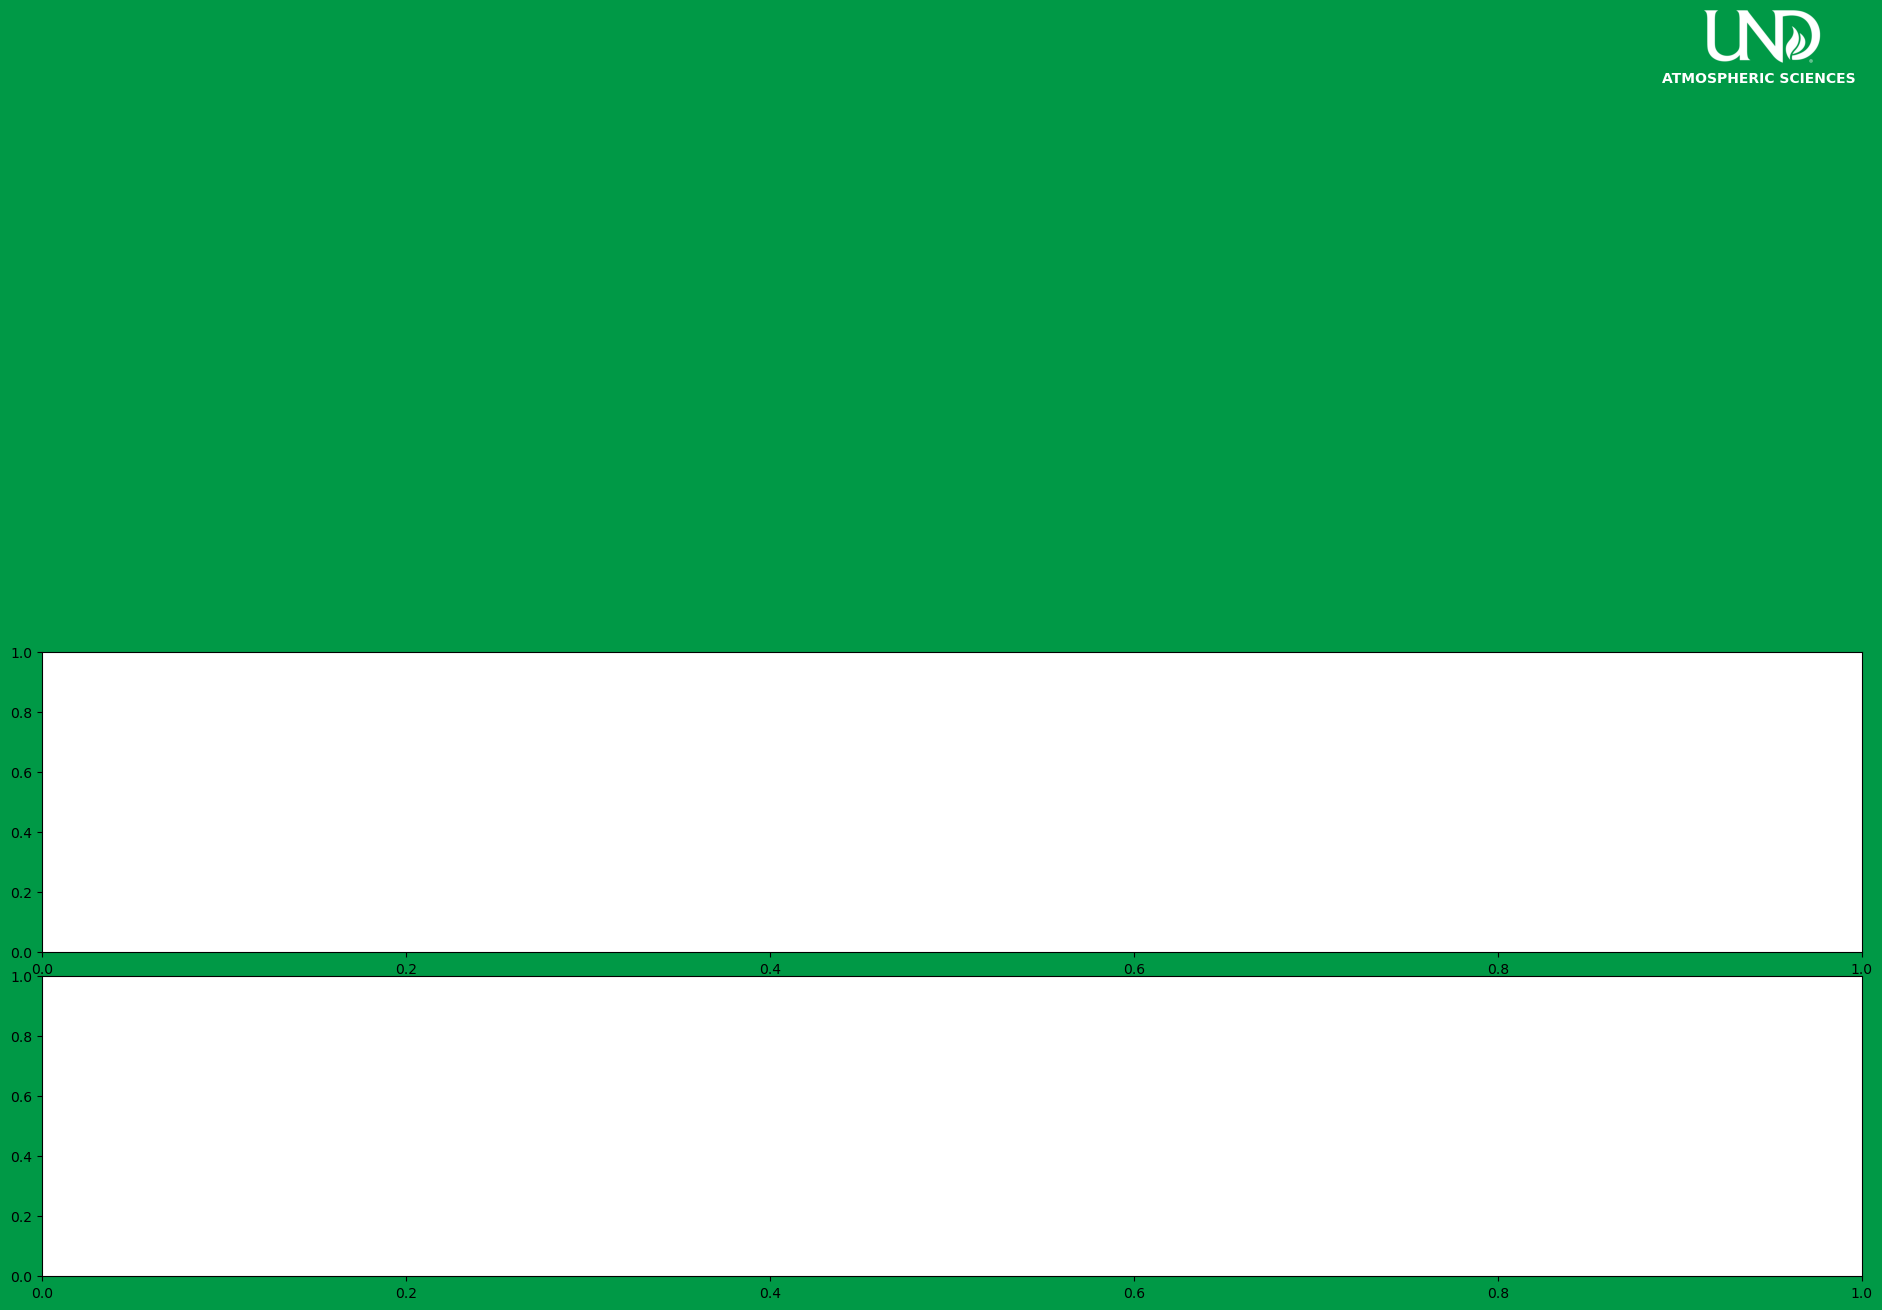

In [ ]:
fig = plt.figure(figsize=(20, 12))
fig.set_facecolor('#009946')

ax1 = plt.axes([0, 0, 0.91, 0.25])
ax2 = plt.axes([0, 0.27, 0.91, 0.25])
ax3 = plt.axes([0, 0.27, 0.91, 0.25])
ax4 = plt.axes([0, 0.27, 0.91, 0.25])

# for ax in [ax1, ax2, ax3, ax4]:
#     ax.set_facecolor('black')
#     ax.tick_params(axis='x', labelsize=12, labelcolor='white')
#     for label in ax.get_xticklabels():
#         label.set_fontweight('bold')
#     ax.patch.set_alpha(1)
#     ax.margins(0)
#     ax.xaxis.set_major_formatter((mdates.DateFormatter('%d'+' | '+'%H:%M'+'Z')))
#     ax.grid(which='major', axis='y', linestyle=(0, (5, 10)), color='white', linewidth=0.5)
#     ax.spines["top"].set_color("white")
#     ax.spines["left"].set_color("white")
#     ax.spines["right"].set_color("white")
#     ax.spines["bottom"].set_color("white")
#     ax.spines["bottom"].set_color("white")


img = Image.open('../utils/images/und-logo.png')
#                  side-side  up-down  size   size
imgax = fig.add_axes([0.83, 1.01, 0.06, 0.06], anchor='SE', zorder=3)
plt.figtext(0.81, 0.995, f'ATMOSPHERIC SCIENCES', ha='left', weight='bold', fontsize=10, color='white')
imgax.imshow(img)
imgax.axis('off')
